# Double Pendulum Tracker
### With interactive colour picker · wall-edge tilt correction · anchor stabilisation

**Workflow:**
1. Set paths in the config cell
2. Pick the green HSV range interactively
3. Click the first pivot (anchor) on a sample frame
4. Click two points on the straight wall edge (tilt correction)
5. Run the tracking loop — positions are exported anchor-relative and tilt-corrected

## 0. Install dependencies (run once)

In [118]:
# Uncomment if needed:
# !pip install opencv-python-headless numpy pandas matplotlib ipywidgets

## 1. Imports & configuration

In [119]:
import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path

# ── CONFIGURATION ──────────────────────────────────────────────
VIDEO_PATH    = input("please provide the path to the video to track").strip()
OUTPUT_CSV    = input("provide the name of the csv file to write to").strip()
PENDULUM_TYPE = input("is this a double pendulum or single pendulum (double/single)").strip().lower()
START_TIME    = input("when should recording start (in seconds)").strip()
END_TIME      = input("when should recording end (in seconds) say 'end' for it to go until the end of data collection").strip()
NUM_FRAMES    = input("how many frames should be tracked? Say 'all' for all frames to be tracked").strip()

START_TIME = float(START_TIME)

if END_TIME == "end": END_TIME = np.inf
else: END_TIME = float(END_TIME)

if NUM_FRAMES == "all": NUM_FRAMES = np.inf
else: NUM_FRAMES = int(NUM_FRAMES)

PREVIEW_DIR   = None    # set to None to skip saving previews
PREVIEW_EVERY = 30                  # save an annotated frame every N frames

# Half-size (px) of the template patch cropped around the anchor for tracking
ANCHOR_PATCH_HALF = 15

# Minimum blob area in pixels (noise filter)
MIN_BLOB_AREA = 50
# ───────────────────────────────────────────────────────────────

# Shared state across cells
state = dict(
    hsv_lower  = np.array([35,  80,  50]),
    hsv_upper  = np.array([85, 255, 255]),
    anchor_px  = None,   # (x, y) clicked in frame 0
    tilt_angle = 0.0,    # radians to rotate all coords by
)

def load_frame(video_path, frame_index=0):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Could not read frame {frame_index} from '{video_path}'")
    return frame  # BGR

def build_mask(bgr, lo, hi, k=5):
    hsv  = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lo, hi)
    ker  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  ker)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, ker)
    return mask

_sample_bgr = load_frame(VIDEO_PATH, frame_index=0)
_sample_rgb = cv2.cvtColor(_sample_bgr, cv2.COLOR_BGR2RGB)
print("Config loaded. Sample frame ready.")

Config loaded. Sample frame ready.


## 2. Interactive colour picker

Drag the sliders until **both tape pieces are bright white** in the mask and the background is black.  
Click **Confirm colour range** when satisfied.

In [120]:
# Slider definitions
sl = {
    k: widgets.IntSlider(
        value=v, min=mn, max=mx, step=1,
        description=k.replace("_", " "),
        style={"description_width": "55px"},
        layout=widgets.Layout(width="430px")
    )
    for k, v, mn, mx in [
        ("H min",  35,  0, 179),
        ("H max",  85,  0, 179),
        ("S min",  80,  0, 255),
        ("S max", 255,  0, 255),
        ("V min",  50,  0, 255),
        ("V max", 255,  0, 255),
    ]
}

confirm_btn  = widgets.Button(
    description="Confirm colour range",
    button_style="success",
    icon="check",
    layout=widgets.Layout(width="210px", margin="10px 0 0 0")
)
status_lbl   = widgets.Label(value="Status: not confirmed yet")
preview_out  = widgets.Output()

def _render(*_):
    lo = np.array([sl["H min"].value, sl["S min"].value, sl["V min"].value])
    hi = np.array([sl["H max"].value, sl["S max"].value, sl["V max"].value])
    mask    = build_mask(_sample_bgr, lo, hi)
    overlay = _sample_rgb.copy()
    overlay[mask == 0] = (overlay[mask == 0] * 0.2).astype(np.uint8)
    with preview_out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].imshow(_sample_rgb);        axes[0].set_title("Original")
        axes[1].imshow(mask, cmap="gray");  axes[1].set_title("Mask (white = detected green)")
        axes[2].imshow(overlay);            axes[2].set_title("Overlay")
        for ax in axes: ax.axis("off")
        plt.tight_layout(); plt.show()

def _confirm(_):
    state["hsv_lower"] = np.array([sl["H min"].value, sl["S min"].value, sl["V min"].value])
    state["hsv_upper"] = np.array([sl["H max"].value, sl["S max"].value, sl["V max"].value])
    status_lbl.value = (
        f"Confirmed  HSV lower = {state['hsv_lower'].tolist()}  "
        f"upper = {state['hsv_upper'].tolist()}"
    )

for s in sl.values():
    s.observe(_render, names="value")
confirm_btn.on_click(_confirm)

display(widgets.VBox([
    widgets.HTML("<b>Hue</b>"),         sl["H min"], sl["H max"],
    widgets.HTML("<b>Saturation</b>"),  sl["S min"], sl["S max"],
    widgets.HTML("<b>Value (brightness)</b>"), sl["V min"], sl["V max"],
    confirm_btn, status_lbl,
]))
display(preview_out)
_render()

Output()

## 3. Select the anchor point (first pivot)

Run this cell. An interactive window will open — **click once on the pivot point** where the pendulum attaches to the support, then close the window.  
Camera shake will be corrected by tracking this point in every frame.

In [121]:
%matplotlib tk
# If tk isn't available, try:  %matplotlib qt  or  %matplotlib osx

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(_sample_rgb)
ax.set_title(
    "Click once on the FIRST PIVOT (anchor point), then close this window",
    fontsize=11, color="firebrick"
)
plt.tight_layout()
pts = plt.ginput(n=1, timeout=0, show_clicks=True)
plt.close(fig)

if pts:
    state["anchor_px"] = np.array(pts[0])
    print(f"Anchor set to pixel ({pts[0][0]:.1f}, {pts[0][1]:.1f})")
else:
    print("No point selected - anchor stabilisation will be skipped.")

%matplotlib inline

Anchor set to pixel (329.3, 185.3)


## 4. Select the wall edge (tilt correction)

Run this cell. An interactive window will open — **click two points along the straight wall edge**.  
Set `EDGE_SHOULD_BE` below to `"horizontal"` or `"vertical"` depending on which edge you click.

In [122]:
%matplotlib tk

EDGE_SHOULD_BE = "vertical"  # <- change to "vertical" if needed

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(_sample_rgb)
ax.set_title(
    f"Click TWO POINTS along the straight wall edge (should be {EDGE_SHOULD_BE}),"
    f" then close this window",
    fontsize=11, color="navy"
)
plt.tight_layout()
pts = plt.ginput(n=2, timeout=0, show_clicks=True)
plt.close(fig)

if len(pts) == 2:
    p1, p2 = np.array(pts[0]), np.array(pts[1])
    dx, dy = p2 - p1
    measured = np.arctan2(dy, dx)
    if EDGE_SHOULD_BE == "horizontal":
        state["tilt_angle"] = -measured
    else:
        state["tilt_angle"] = -(measured - np.pi / 2)
    deg = np.degrees(state["tilt_angle"])
    print(f"Tilt correction: {deg:.3f} degrees will be applied to all tracked coordinates")

    # Visual confirmation
    fig2, ax2 = plt.subplots(figsize=(10, 7))
    ax2.imshow(_sample_rgb)
    ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], "b-", lw=2.5, label="Selected edge")
    ax2.scatter([p1[0], p2[0]], [p1[1], p2[1]], c="cyan", zorder=5, s=80)
    ax2.set_title(f"Wall edge selected  |  tilt correction = {deg:.3f} deg", fontsize=11)
    ax2.legend(); ax2.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Need 2 points - tilt correction will be skipped (angle = 0).")

%matplotlib inline

Tilt correction: 0.781 degrees will be applied to all tracked coordinates


## 5. Core tracking functions

In [123]:
def blob_stats(mask, min_area=50):
    """
    Find up to 2 largest blobs in a binary mask.
    Returns list of dicts: cx, cy (centroid), sigma_x/y (weighted spread), area.
    """
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    blobs = []
    for lbl in range(1, n):
        area = int(stats[lbl, cv2.CC_STAT_AREA])
        if area < min_area:
            continue
        ys, xs = np.where(labels == lbl)
        w  = mask[ys, xs].astype(float)
        cx = float(np.average(xs, weights=w))
        cy = float(np.average(ys, weights=w))
        sx = float(np.sqrt(np.average((xs - cx) ** 2, weights=w)))
        sy = float(np.sqrt(np.average((ys - cy) ** 2, weights=w)))
        blobs.append(dict(cx=cx, cy=cy, sigma_x=sx, sigma_y=sy, area=area))
    blobs.sort(key=lambda b: b["area"], reverse=True)
    return blobs[:2]


def sort_by_continuity(blobs, prev):
    """Maintain consistent marker IDs by nearest-neighbour matching to previous frame."""
    if len(blobs) != 2 or len(prev) != 2:
        return blobs
    d = lambda a, b: (a["cx"] - b["cx"]) ** 2 + (a["cy"] - b["cy"]) ** 2
    if d(blobs[0], prev[1]) + d(blobs[1], prev[0]) < d(blobs[0], prev[0]) + d(blobs[1], prev[1]):
        blobs = [blobs[1], blobs[0]]
    return blobs


def track_anchor_template(frame_bgr, template):
    """
    Find the best match for `template` in `frame_bgr` using normalised cross-correlation.
    Returns the centre (cx, cy) of the best-matching region.
    """
    gray_f = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    gray_t = cv2.cvtColor(template,  cv2.COLOR_BGR2GRAY)
    result = cv2.matchTemplate(gray_f, gray_t, cv2.TM_CCOEFF_NORMED)
    _, _, _, max_loc = cv2.minMaxLoc(result)
    th, tw = gray_t.shape
    return max_loc[0] + tw / 2, max_loc[1] + th / 2


def rotate_point(x, y, angle_rad):
    """Rotate (x, y) around the origin by angle_rad."""
    c, s = np.cos(angle_rad), np.sin(angle_rad)
    return c * x - s * y, s * x + c * y


NAN_BLOB = dict(cx=np.nan, cy=np.nan, sigma_x=np.nan, sigma_y=np.nan, area=0)

print("Tracking functions defined.")

Tracking functions defined.


## 6. Build anchor template

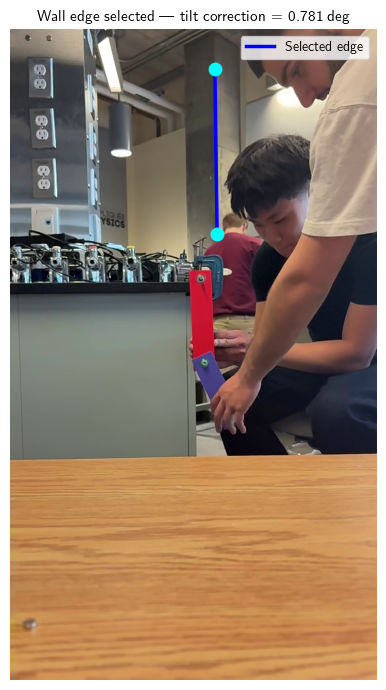

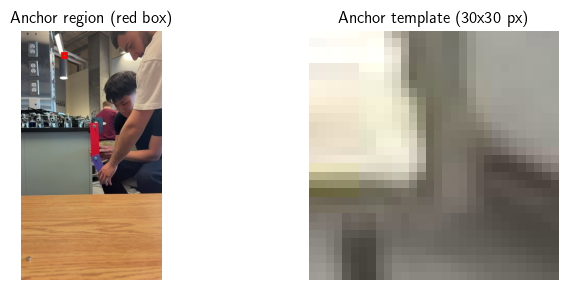

In [124]:
anchor_template = None
anchor0         = state["anchor_px"]

if anchor0 is not None:
    ax0, ay0 = int(round(anchor0[0])), int(round(anchor0[1]))
    H0, W0   = _sample_bgr.shape[:2]
    ph       = ANCHOR_PATCH_HALF
    x1, x2   = max(0, ax0 - ph), min(W0, ax0 + ph)
    y1, y2   = max(0, ay0 - ph), min(H0, ay0 + ph)
    anchor_template = _sample_bgr[y1:y2, x1:x2].copy()

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(_sample_rgb)
    axes[0].add_patch(plt.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="red", facecolor="none"
    ))
    axes[0].set_title("Anchor region (red box)")
    axes[1].imshow(cv2.cvtColor(anchor_template, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Anchor template  ({anchor_template.shape[1]}x{anchor_template.shape[0]} px)")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No anchor selected - camera stabilisation disabled.")

## 7. Run tracking over the full video

In [125]:
from pathlib import Path
import cv2
import numpy as np

# ---------------------------------------------

if PREVIEW_DIR is not None:
    Path(PREVIEW_DIR).mkdir(exist_ok=True)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: '{VIDEO_PATH}'")

fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Video: {n_frames} frames @ {fps:.2f} fps  |  {W}x{H} px")

# NEW: Fast-forward to your start time
cap.set(cv2.CAP_PROP_POS_MSEC, START_TIME * 1000)

# NEW: Set frame_idx to where the video actually jumped to
# This ensures "time_s" in your records stays perfectly synchronized!
frame_idx = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
print(
    f"Skipped to frame {frame_idx} at approx {START_TIME} seconds to start collection."
)

tilt = state["tilt_angle"]
use_anchor = anchor_template is not None
ref_anchor = anchor0.copy() if anchor0 is not None else np.zeros(2)
print(
    f"Tilt correction: {np.degrees(tilt):.3f} deg  |  Anchor stabilisation: {use_anchor}"
)

records = []
prev_blobs = []

frames_tracked = -1
while True:
    frames_tracked += 1
    if frames_tracked >= NUM_FRAMES:
        break

    ret, frame_bgr = cap.read()
    if not ret:
        break

    # NEW: Calculate the real-time position in the video
    time_s = frame_idx / fps

    # NEW: Check if we have exceeded the designated end time
    if time_s >= END_TIME:
        print(
            f"Reached END_TIME ({END_TIME}s). Stopping collection automatically."
        )
        break

    # 1. Locate anchor in this frame
    if use_anchor:
        anc_cx, anc_cy = track_anchor_template(frame_bgr, anchor_template)
    else:
        anc_cx, anc_cy = ref_anchor[0], ref_anchor[1]

    # 2. Detect green blobs
    mask = build_mask(frame_bgr, state["hsv_lower"], state["hsv_upper"])
    blobs = blob_stats(mask, min_area=MIN_BLOB_AREA)

    # Restrict to 1 blob if single pendulum selected
    if PENDULUM_TYPE == "single":
        blobs = blobs[:1]

    blobs = sort_by_continuity(blobs, prev_blobs)
    while len(blobs) < 2:
        blobs.append(NAN_BLOB.copy())

    # 3. Stabilise + tilt-correct each blob
    def correct(b):
        if np.isnan(b["cx"]):
            return b
        # Express relative to anchor (removes camera shake)
        x = b["cx"] - anc_cx
        y = -(b["cy"] - anc_cy)
        # Rotate to correct camera tilt
        x, y = rotate_point(x, y, tilt)
        # Propagate uncertainty through rotation
        c, s = abs(np.cos(tilt)), abs(np.sin(tilt))
        sx = c * b["sigma_x"] + s * b["sigma_y"]
        sy = s * b["sigma_x"] + c * b["sigma_y"]
        return dict(cx=x, cy=y, sigma_x=sx, sigma_y=sy, area=b["area"])

    b0, b1 = correct(blobs[0]), correct(blobs[1])

    records.append(
        {
            "frame": frame_idx,
            "time_s": time_s,  # Using the continuous calculated time
            "x1": b0["cx"],
            "y1": b0["cy"],
            "sigma_x1": b0["sigma_x"],
            "sigma_y1": b0["sigma_y"],
            "area1": b0["area"],
            "x2": b1["cx"],
            "y2": b1["cy"],
            "sigma_x2": b1["sigma_x"],
            "sigma_y2": b1["sigma_y"],
            "area2": b1["area"],
            "anchor_x": anc_cx,
            "anchor_y": anc_cy,
        }
    )
    prev_blobs = blobs

    # 4. Annotated preview frame
    if PREVIEW_DIR and frame_idx % PREVIEW_EVERY == 0:
        vis = frame_bgr.copy()
        for raw_b, colour in zip(blobs, [(0, 255, 0), (0, 200, 255)]):
            if not np.isnan(raw_b["cx"]):
                px, py = int(round(raw_b["cx"])), int(round(raw_b["cy"]))
                r = max(
                    3, int(round(max(raw_b["sigma_x"], raw_b["sigma_y"])))
                )
                cv2.circle(vis, (px, py), r, colour, 2)
                cv2.drawMarker(vis, (px, py), colour, cv2.MARKER_CROSS, 12, 2)
        cv2.drawMarker(
            vis,
            (int(round(anc_cx)), int(round(anc_cy))),
            (0, 0, 255),
            cv2.MARKER_STAR,
            18,
            2,
        )
        cv2.imwrite(f"{PREVIEW_DIR}/frame_{frame_idx:05d}.jpg", vis)

    frame_idx += 1
    if frame_idx % 100 == 0:
        # Adjusted print statement to show frames based on your custom script's print style
        print(f"  {frame_idx}/{min(n_frames, NUM_FRAMES)} frames…")

cap.release()
print(f"Done. {len(records)} frames tracked.")

Video: 14133 frames @ 239.48 fps  |  1080x1920 px
Skipped to frame 599 at approx 2.5 seconds to start collection.
Tilt correction: 0.781 deg  |  Anchor stabilisation: True
  600/14133 frames…
  700/14133 frames…
  800/14133 frames…
  900/14133 frames…
  1000/14133 frames…
  1100/14133 frames…
  1200/14133 frames…
  1300/14133 frames…
  1400/14133 frames…
  1500/14133 frames…
  1600/14133 frames…
  1700/14133 frames…
  1800/14133 frames…
  1900/14133 frames…
  2000/14133 frames…
  2100/14133 frames…
  2200/14133 frames…
  2300/14133 frames…
  2400/14133 frames…
  2500/14133 frames…
  2600/14133 frames…
  2700/14133 frames…
  2800/14133 frames…
  2900/14133 frames…
  3000/14133 frames…
  3100/14133 frames…
  3200/14133 frames…
  3300/14133 frames…
  3400/14133 frames…
  3500/14133 frames…
  3600/14133 frames…
  3700/14133 frames…
  3800/14133 frames…
  3900/14133 frames…
  4000/14133 frames…
  4100/14133 frames…
  4200/14133 frames…
  4300/14133 frames…
  4400/14133 frames…
  4500/14133 

## 7.1 Loading and processing the data

In [126]:
df = pd.DataFrame(records)
filled_df = df.interpolate(method='linear', axis=0, limit_direction='both')
float_cols = ["time_s",
              "x1", "y1", "sigma_x1", "sigma_y1",
              "x2", "y2", "sigma_x2", "sigma_y2",
              "anchor_x", "anchor_y"]

data_preprocess = filled_df[float_cols].to_numpy()

data = data_preprocess[:, :9].copy() #anchor positions arent important
# data[:, 0] = data_preprocess[:, 0] * 30/240.33 # the video is actually 240.33 fps, despite what the .mov file says

I want to find the actual center of the pendulum reliably. The first arm moves in a circle around this point. I will find the center by fitting a function for the bottom half of a circle to this data.

In [127]:
from scipy.optimize import curve_fit

In [128]:
if PENDULUM_TYPE == 'single':
    arm_pos = data[:, 1:3]
else:
    arm_pos = data[:, 5:7]

arm2_mean = np.mean(arm_pos, axis=0)
arm2_max = np.max(arm_pos, axis=0)
arm2_min = np.min(arm_pos, axis=0)

# we want to get the cutoff to get only the bottom half of the circle. this would likely happen at the y-level of furthest-protruding x positions
arm2_y_cutoff = 0.5 * (arm_pos[np.argmax(arm_pos[:, 0]), 1] + arm_pos[np.argmin(arm_pos[:, 0]), 1])

# applying the cutoff
arm_pos = arm_pos[arm_pos[:, 1] < arm2_y_cutoff]

In [129]:
def circle_lower(x, R, h_off, v_off):
    A = (R**2 - (x - h_off)**2).clip(min=0)
    return -np.sqrt(A) + v_off

In [130]:
min_radius = (arm2_max[0] - arm2_min[0]) / 2.5 # divided by 2.5 and not 2 because if the full circle is seen then the min radius may be a tiny bit bigger than the actual radius (due to random jitter)
max_radius = 10*min_radius #this is a bit arbitrary and depends on how high the pendulum was able to go...
print(min_radius, max_radius)

min_x = arm2_min[0]
max_x = arm2_max[0]

min_y = arm2_min[1]
max_y = min_y + 2*max_radius

(arm2_radius, pivot_x, pivot_y), pcov = curve_fit(circle_lower, arm_pos[:, 0], arm_pos[:, 1], bounds=([min_radius, min_x, min_y], [max_radius, max_x, max_y]))
(arm2_radius_err, pivot_x_err, pivot_y_err) = np.sqrt(np.diag(pcov))

print(arm2_radius, pivot_x, pivot_y, arm2_radius_err, pivot_x_err, pivot_y_err)

6.101880787152686 61.01880787152686
61.018807860739265 259.5135718452441 -737.014661507788 2.5369052371069745 0.07032051523653532 2.5430423307405032


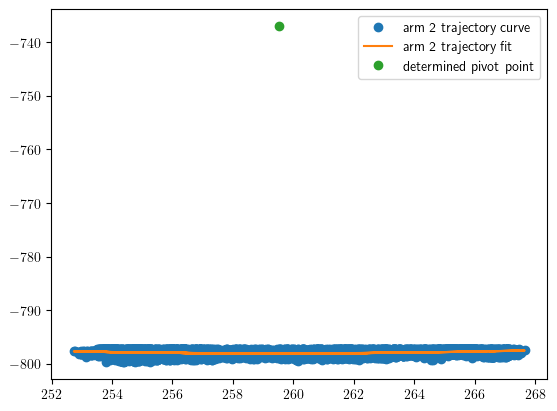

In [131]:
plt.plot(arm_pos[:, 0], arm_pos[:, 1], 'o', label="arm 2 trajectory curve")
plt.plot(arm_pos[:, 0], circle_lower(arm_pos[:, 0], arm2_radius, pivot_x, pivot_y), label="arm 2 trajectory fit")
plt.plot(pivot_x, pivot_y, 'o', label="determined pivot point")
plt.legend()

# plt.plot(arm_pos[:, 0], circle_lower(arm_pos[:, 0], 100, 0, 0))

In [132]:
data[:, 1] = data_preprocess[:, 1] - pivot_x
data[:, 2] = data_preprocess[:, 2] - pivot_y
data[:, 5] = data_preprocess[:, 5] - pivot_x
data[:, 6] = data_preprocess[:, 6] - pivot_y

## 7.2 Getting the angles

In [133]:
def phase_unwrap(data):
    for j in range(0, len(data) - 1):
        i = j + 1
        while (data[i] - data[i - 1] > np.pi):
            data[i] -= 2*np.pi
        while (data[i - 1] - data[i] > np.pi):
            data[i] += 2*np.pi

In [134]:
if PENDULUM_TYPE == 'single':
    rel1_x = data[:, 1]
    rel1_y = data[:, 2]

    rel1_x_err = data[:, 3]
    rel1_y_err = data[:, 4]

    angle1 = np.arctan2(rel1_x, rel1_y) + np.pi
    angle2 = np.full_like(angle1, np.nan)

    angle1_err = np.hypot(
        rel1_x_err * 1/((1 + (rel1_x / rel1_y)**2) * rel1_y),
        rel1_y_err * rel1_x/((1 + (rel1_x / rel1_y)**2) * rel1_y**2),
    )
    angle2_err = np.full_like(angle1_err, np.nan)

    phase_unwrap(angle1)
else:
    # relative positions of the two pivot points to use for angle1
    rel1_x = data[:, 1] - data[:, 5]
    rel1_y = data[:, 2] - data[:, 6]

    rel1_x_err = np.hypot(data[:, 1 + 2], data[:, 5 + 2])
    rel1_y_err = np.hypot(data[:, 2 + 2], data[:, 6 + 2])

    angle1 = np.arctan2(rel1_x, rel1_y) + np.pi
    angle2 = np.arctan2(data[:, 5], data[:, 6]) + np.pi

    angle1_err = np.hypot(
        rel1_x_err * 1/((1 + (rel1_x / rel1_y)**2) * rel1_y),
        rel1_y_err * rel1_x/((1 + (rel1_x / rel1_y)**2) * rel1_y**2),
    )
    angle2_err = np.hypot(
        data[:, 5 + 2] * 1/((1 + (data[:, 5] / data[:, 6])**2) * data[:, 6]),
        data[:, 6 + 2] * data[:, 5]/((1 + (data[:, 5] / data[:, 6])**2) * data[:, 6]**2),
    )

    phase_unwrap(angle1)
    phase_unwrap(angle2)

data = np.hstack((
    data,
    np.vstack((angle1, angle2, angle1_err, angle2_err)).transpose()
))

## 8. Export to CSV

In [135]:
np.savetxt(OUTPUT_CSV, data, delimiter=",", fmt="%f", header="time (s), x1 (pixels), y1 (pixels), x1 error (pixels), y1 error (pixels), x2 (pixels), y2 (pixels), x2 error (pixels), y2 error (pixels), angle1 (the smaller arm) (rad), angle2 (the larger arm) (rad), angle1 error (rad), angle2 error (rad)")

## 9. Sanity-check plots

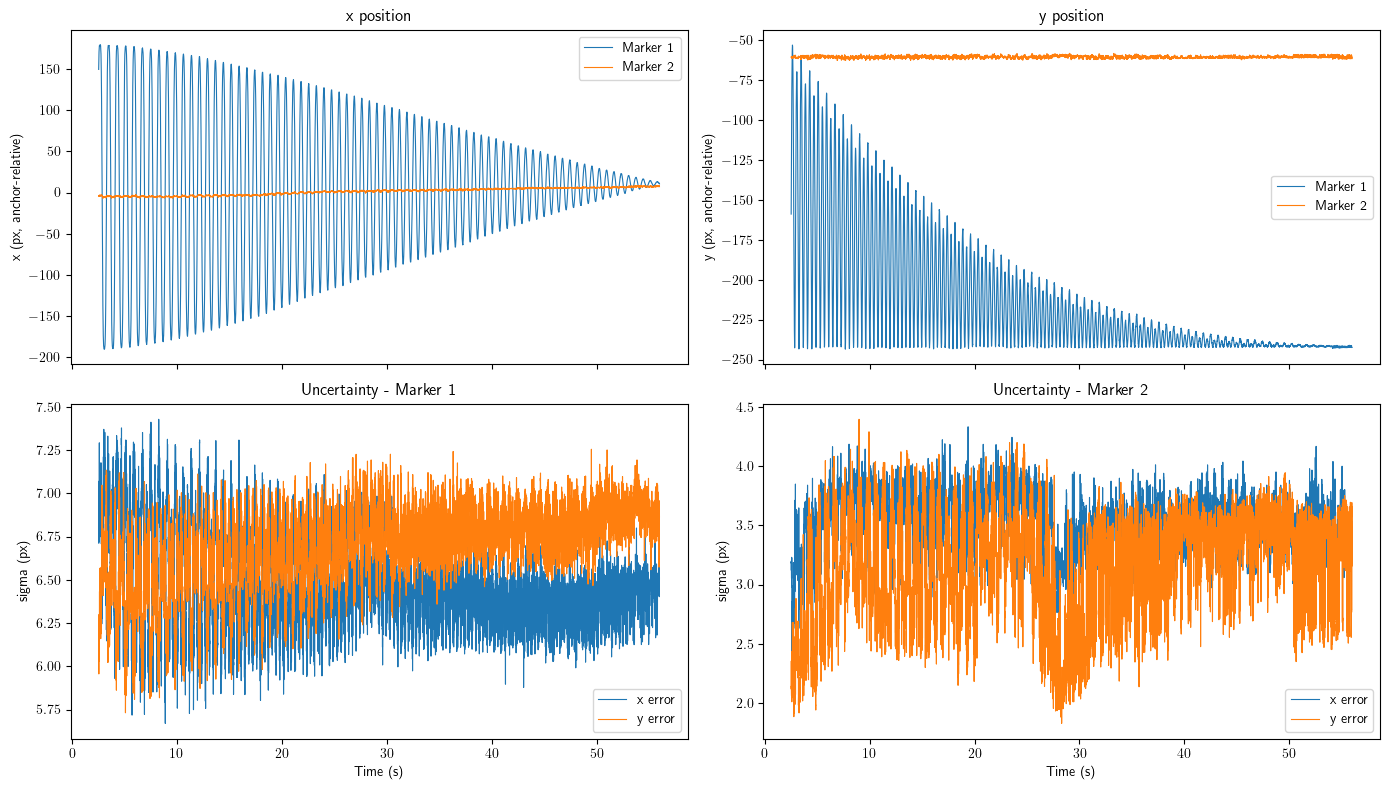

In [136]:
t = df["time_s"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

axes[0,0].plot(t, data[:, 1], lw=0.8, label="Marker 1"); axes[0,0].plot(t, data[:, 5], lw=0.8, label="Marker 2")
axes[0,0].set_ylabel("x (px, anchor-relative)"); axes[0,0].set_title("x position"); axes[0,0].legend()

axes[0,1].plot(t, data[:, 2], lw=0.8, label="Marker 1"); axes[0,1].plot(t, data[:, 6], lw=0.8, label="Marker 2")
axes[0,1].set_ylabel("y (px, anchor-relative)"); axes[0,1].set_title("y position"); axes[0,1].legend()

axes[1,0].plot(t, data[:, 3], lw=0.8, label="x error"); axes[1,0].plot(t, data[:, 4], lw=0.8, label="y error")
axes[1,0].set_xlabel("Time (s)"); axes[1,0].set_ylabel("sigma (px)"); axes[1,0].set_title("Uncertainty - Marker 1"); axes[1,0].legend()

axes[1,1].plot(t, data[:, 7], lw=0.8, label="x error"); axes[1,1].plot(t, data[:, 8], lw=0.8, label="y error")
axes[1,1].set_xlabel("Time (s)"); axes[1,1].set_ylabel("sigma (px)"); axes[1,1].set_title("Uncertainty - Marker 2"); axes[1,1].legend()

plt.tight_layout(); plt.savefig("tracking_overview.png", dpi=150); plt.show()

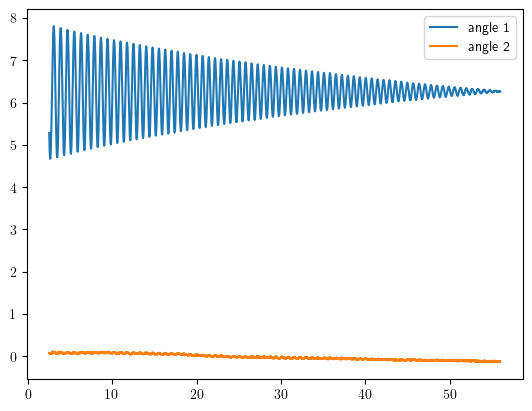

In [137]:
plt.plot(t, data[:, 9], label="angle 1"); plt.plot(t, data[:, 10], label="angle 2")
plt.legend()

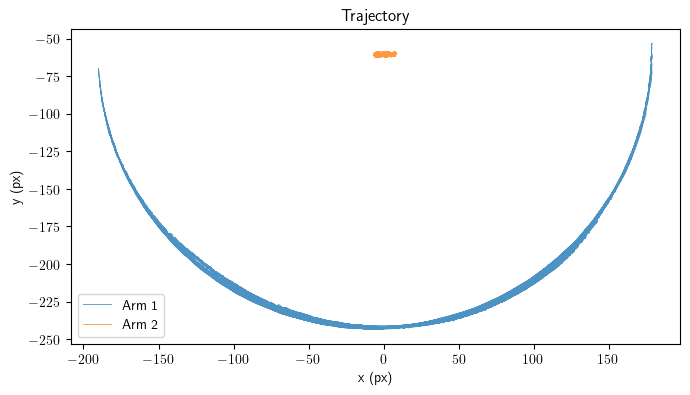

In [138]:
# XY trajectory
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(data[:, 1], data[:, 2], lw=0.6, alpha=0.8, label="Arm 1")
if PENDULUM_TYPE == 'double':
    ax.plot(data[:, 5], data[:, 6], lw=0.6, alpha=0.8, label="Arm 2")
ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")
ax.set_title("Trajectory")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.savefig("trajectory.png", dpi=150); plt.show()

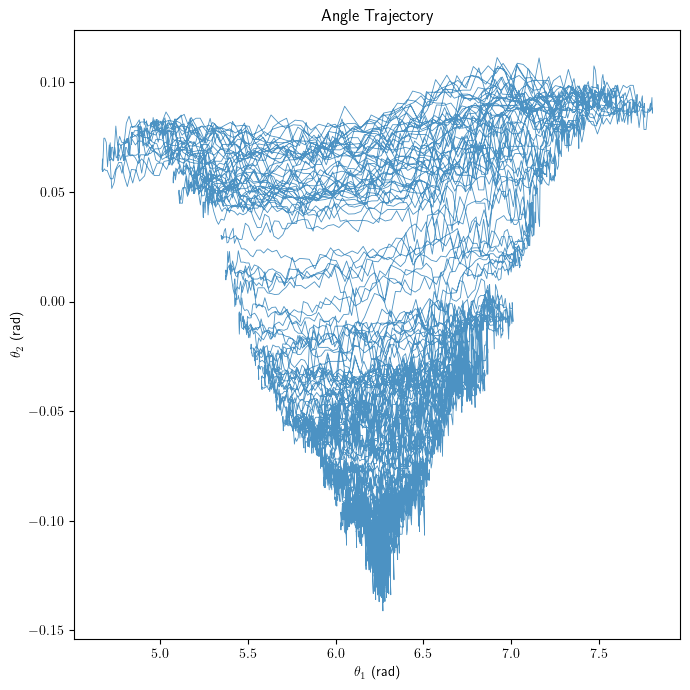

In [139]:
# angle trajectory
fig, ax = plt.subplots(figsize=(7, 7))
if PENDULUM_TYPE == 'single':
    ax.plot(df["time_s"], data[:, 9], lw=0.6, alpha=0.8, label="Arm 1")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("$\\theta_1$ (rad)")
else:
    ax.plot(data[:, 9], data[:, 10], lw=0.6, alpha=0.8)
    ax.set_xlabel("$\\theta_1$ (rad)"); ax.set_ylabel("$\\theta_2$ (rad)")
    
ax.set_title("Angle Trajectory")
plt.tight_layout(); plt.savefig("angle_trajectory.png", dpi=150); plt.show()

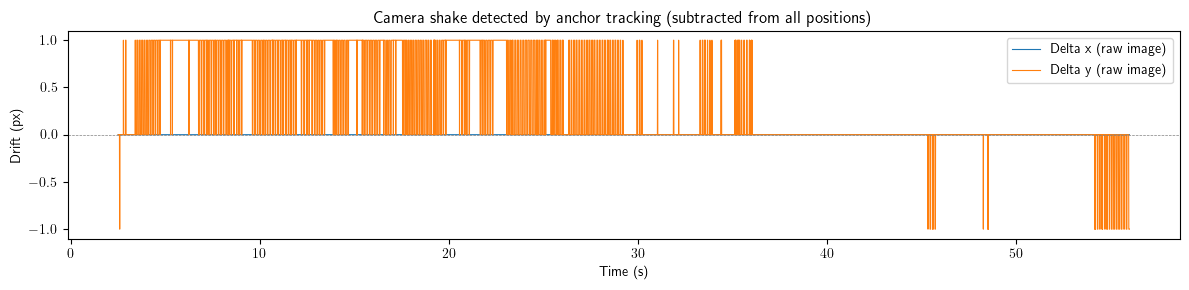

In [140]:
# Anchor drift (camera shake that was corrected)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, df["anchor_x"] - df["anchor_x"].iloc[0], lw=0.8, label="Delta x (raw image)")
ax.plot(t, df["anchor_y"] - df["anchor_y"].iloc[0], lw=0.8, label="Delta y (raw image)")
ax.axhline(0, color="grey", lw=0.5, ls="--")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Drift (px)")
ax.set_title("Camera shake detected by anchor tracking (subtracted from all positions)")
ax.legend(); plt.tight_layout(); plt.savefig("anchor_drift.png", dpi=150); plt.show()

## 10. Reference

### CSV columns

| Column | Description |
|---|---|
| `frame` | Frame index (0-based) |
| `time_s` | Time in seconds |
| `x1`, `y1` | Marker 1 centroid — anchor-relative, tilt-corrected (px) |
| `sigma_x1`, `sigma_y1` | Marker 1 uncertainty (px, 1-sigma) — blob spread + rotation propagation |
| `area1` | Marker 1 blob area (px^2) — useful as detection quality metric |
| `x2`, `y2` | Marker 2 centroid — anchor-relative, tilt-corrected (px) |
| `sigma_x2`, `sigma_y2` | Marker 2 uncertainty (px, 1-sigma) |
| `area2` | Marker 2 blob area (px^2) |
| `anchor_x`, `anchor_y` | Raw image-coord anchor position each frame (diagnostic only) |

> **Origin:** (0, 0) = first pivot. x rightward, y downward (image convention). Negate y for a physics coordinate system.
> **Scaling:** multiply all position/uncertainty columns by `1 / px_per_mm` if you have a ruler in frame.

### Troubleshooting

| Problem | Fix |
|---|---|
| Anchor drifting wildly | Increase `ANCHOR_PATCH_HALF`; ensure pivot area has distinct texture |
| Blobs merging into one | Tighten HSV range or raise `MIN_BLOB_AREA` |
| Marker IDs swapping | Arms crossing often — consider starting from a specific frame or adding Kalman filtering |
| Many NaN rows | Lower `S_min`/`V_min`; check lighting consistency across the video |
| `.mov` file won't open | Install `ffmpeg` and reinstall `opencv-python-headless` with ffmpeg support |